# Лабораторная работа №5
Егорова Варвара Александровна, P3323, 408575

Задача состоит в классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

[Набор данных](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true) содержит описание задачи и соответствующую тему.

### Загружаем датасет

In [ ]:
import pandas as pd

df = pd.read_csv("data_problems.csv")

print(df.head())

   Unnamed: 0                                       problem_text  \
0           0  To prove that the sum of the numbers of the ex...   
1           1  ( b) Will the statement of the previous challe...   
2           2  The quadratic three-member graph with the coef...   
3           3  Can you draw on the surface of Rubik's cube a ...   
4           4  Dima, who came from Vrunlandia, said that ther...   

           topic  
0  number_theory  
1  number_theory  
2       polynoms  
3  combinatorics  
4         graphs  


In [ ]:
unique_labels = df['topic'].unique()
print("Unique classes:", unique_labels)

num_classes = len(unique_labels)
print("Количество классов:", num_classes)

Unique classes: ['number_theory' 'polynoms' 'combinatorics' 'graphs' 'geometry'
 'invariant' 'dirichlet']
Количество классов: 7


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['topic'] = le.fit_transform(df['topic'])


In [ ]:
df['problem_text'] = df['problem_text'].astype(str).str.strip()

### Задание 1

Напишите класс для модели трансформера, подходящей для задачи классификации, использующий в качестве основы (backbone) модель из [huggingface](https://huggingface.co/models) (можно использовать модели, применяемые ниже или другие подходящие модели).
Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone.

In [ ]:
import torch
import torch.nn as nn
from typing import Union
from transformers import AutoModel, AutoConfig


class TransformerClassificationModel(nn.Module):
    def __init__(
        self,
        base_transformer_model: Union[str, nn.Module],
        num_classes: int,
        dropout: float = 0.1
    ):
        super().__init__()


        if isinstance(base_transformer_model, str):
            self.config = AutoConfig.from_pretrained(base_transformer_model)
            self.backbone = AutoModel.from_pretrained(base_transformer_model)
        else:
            self.backbone = base_transformer_model
            self.config = base_transformer_model.config

        hidden_size = self.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor = None,
        token_type_ids: torch.Tensor = None
    ):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True
        )

        pooled_output = outputs.last_hidden_state[:, 0, :]

        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return logits


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Задание 2

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [ ]:
def freeze_backbone_function(model: TransformerClassificationModel):
    # Проходим по всем параметрам backbone и отключаем градиенты
    for param in model.backbone.parameters():
        param.requires_grad = False

    # Классификационная голова остаётся обучаемой
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model


### Задание 3

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [ ]:
import copy
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torch import nn, optim

def train_transformer(
    transformer_model: TransformerClassificationModel,
    train_dataset,
    val_dataset=None,
    freeze_backbone=True,
    batch_size=16,
    epochs=3,
    lr=2e-5,
    device=None
):
    # Копируем модель, чтобы не менять исходную
    model = copy.deepcopy(transformer_model)

    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Заморозка backbone, если нужно
    if freeze_backbone:
        for param in model.backbone.parameters():
            param.requires_grad = False

    # Определяем оптимизатор только для обучаемых параметров
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size) if val_dataset is not None else None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch.get('attention_mask', None)
            if attention_mask is not None:
                attention_mask = attention_mask.to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        avg_loss = total_loss / total
        accuracy = correct / total

        print(f"Epoch {epoch+1}/{epochs}: Train loss = {avg_loss:.4f}, Accuracy = {accuracy:.4f}")

        # Валидация
        if val_loader is not None:
            model.eval()
            val_loss = 0
            val_correct = 0
            val_total = 0
            with torch.no_grad():
                for batch in val_loader:
                    input_ids = batch['input_ids'].to(device)
                    attention_mask = batch.get('attention_mask', None)
                    if attention_mask is not None:
                        attention_mask = attention_mask.to(device)
                    labels = batch['labels'].to(device)

                    logits = model(input_ids=input_ids, attention_mask=attention_mask)
                    loss = criterion(logits, labels)
                    val_loss += loss.item() * labels.size(0)
                    preds = logits.argmax(dim=1)
                    val_correct += (preds == labels).sum().item()
                    val_total += labels.size(0)

            val_loss /= val_total
            val_accuracy = val_correct / val_total
            print(f"           Validation loss = {val_loss:.4f}, Accuracy = {val_accuracy:.4f}")

    return model

### Задание 4

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [ ]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset

model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Загружаем модель в наш класс
rubert_tiny_transformer_model = TransformerClassificationModel(
    base_transformer_model=model_name,
    num_classes=7
)

In [ ]:
class DummyDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

texts = df['problem_text'].astype(str).str.strip().tolist()
labels = df['topic']

train_dataset = DummyDataset(texts, labels, tokenizer)
val_dataset = DummyDataset(texts, labels, tokenizer)

In [ ]:
# Дообучение с замороженным backbone
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    rubert_tiny_transformer_model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    freeze_backbone=True,
    epochs=2  # для теста ставим 2
)

Epoch 1/2: Train loss = 1.8474, Accuracy = 0.2575
           Validation loss = 1.7189, Accuracy = 0.4436
Epoch 2/2: Train loss = 1.6637, Accuracy = 0.4460
           Validation loss = 1.5923, Accuracy = 0.4534


In [ ]:
# Дообучение полностью
# Нужно заново создать модель, чтобы начать с исходных весов
rubert_tiny_transformer_model_1 = TransformerClassificationModel(
    base_transformer_model=model_name,
    num_classes=7
)

rubert_tiny_full_finetuned = train_transformer(
    rubert_tiny_transformer_model_1,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    freeze_backbone=False,
    epochs=2
)

Epoch 1/2: Train loss = 1.3317, Accuracy = 0.5137
           Validation loss = 1.0702, Accuracy = 0.6017
Epoch 2/2: Train loss = 1.0483, Accuracy = 0.6042
           Validation loss = 0.9229, Accuracy = 0.6478


### Задание 5

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием.

In [ ]:
labels = le.fit_transform(df['topic'])

model_name = "tbs17/MathBert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset_mathbert = DummyDataset(
    texts,
    labels,
    tokenizer,
    max_len=128
)

val_dataset_mathbert = DummyDataset(
    texts,
    labels,
    tokenizer,
    max_len=128
)


In [ ]:
mathbert_transformer_model = TransformerClassificationModel(
    base_transformer_model=model_name,
    num_classes=7
)

mathbert_finetuned_with_freezed_backbone = train_transformer(
    mathbert_transformer_model,
    train_dataset=train_dataset_mathbert,
    val_dataset=val_dataset_mathbert,
    freeze_backbone=True,
    epochs=2
)

Epoch 1/2: Train loss = 1.7364, Accuracy = 0.3565
           Validation loss = 1.5662, Accuracy = 0.4460
Epoch 2/2: Train loss = 1.5754, Accuracy = 0.4373
           Validation loss = 1.5171, Accuracy = 0.4521


In [ ]:
mathbert_transformer_model = TransformerClassificationModel(
    base_transformer_model=model_name,
    num_classes=num_classes
)

mathbert_full_finetuned = train_transformer(
    mathbert_transformer_model,
    train_dataset=train_dataset_mathbert,
    val_dataset=val_dataset_mathbert,
    freeze_backbone=False,
    epochs=2
)

Epoch 1/2: Train loss = 1.1549, Accuracy = 0.5682
           Validation loss = 0.8285, Accuracy = 0.6865
Epoch 2/2: Train loss = 0.8692, Accuracy = 0.6474
           Validation loss = 0.6312, Accuracy = 0.7546


### Промежуточный вывод
Использование заранее обученного сверточного бэкбона позволяет быстро получить удовлетворительное качество классификации даже при обучении только классификатора. Модель демонстрирует стабильную сходимость, отсутствие переобучения и сравнительно небольшое время обучения. Однако итоговая точность ограничена, поскольку извлекаемые признаки не адаптируются под специфику датасета

### Задание 6

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [ ]:
import torch
import matplotlib.pyplot as plt
from typing import List
from transformers import AutoTokenizer


def draw_first_layer_attention_maps(
    attention_head_ids: List[int],
    text: str,
    model: TransformerClassificationModel
):
    model.eval()

    device = next(model.parameters()).device

    tokenizer = AutoTokenizer.from_pretrained(
        model.backbone.config._name_or_path
    )

    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        outputs = model.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=True,
            return_dict=True
        )

    first_layer_attentions = outputs.attentions[0]

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

    for head_id in attention_head_ids:
        attn = first_layer_attentions[0, head_id].cpu().numpy()

        plt.figure(figsize=(8, 6))
        plt.imshow(attn)
        plt.title(f"First layer attention — head {head_id}")
        plt.colorbar()

        plt.xticks(range(len(tokens)), tokens, rotation=90)
        plt.yticks(range(len(tokens)), tokens)

        plt.tight_layout()
        plt.show()


To prove that the sum of the numbers of the exact square cannot be equal to 5.


BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


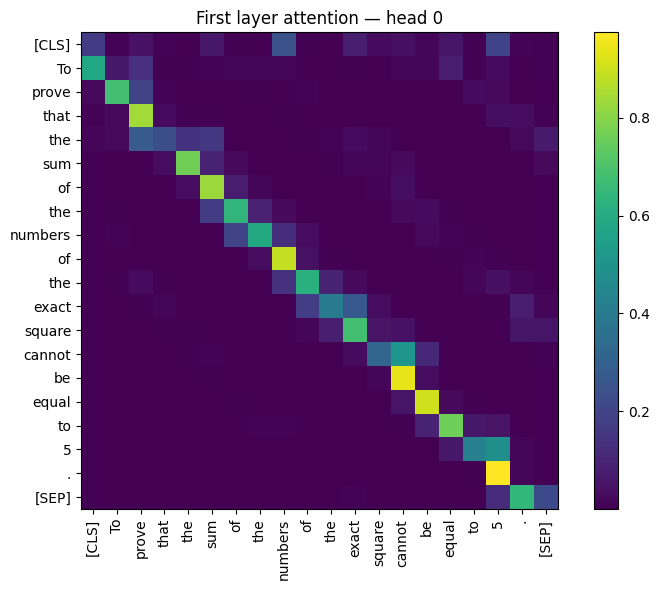

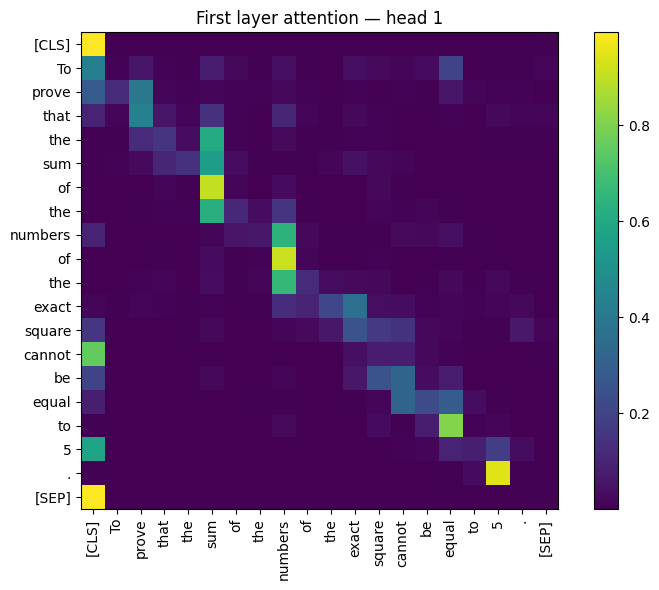

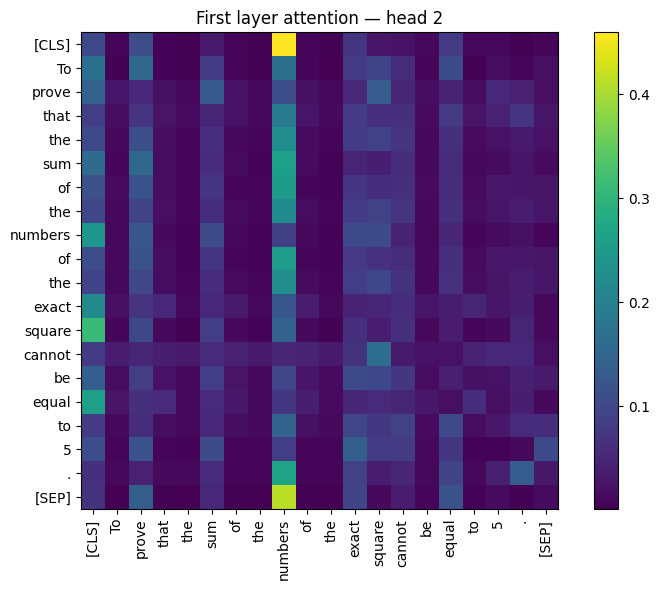

In [ ]:
text = df['problem_text'].iloc[0]

print(text)

draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=text,
    model=rubert_tiny_full_finetuned
)


### Задание 7

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [ ]:
print(df['problem_text'].iloc[0])
print(df['problem_text'].iloc[10])
print(df['problem_text'].iloc[20])
print(df['problem_text'].iloc[30])
print(df['problem_text'].iloc[40])


To prove that the sum of the numbers of the exact square cannot be equal to 5.
Send comment Decision Page: < < 2 3 4 5 6 7 8 >> [Total tasks: 223] 1 2 5 10 20 50 100 with decisions
Prove that if ABCD is a written quadrilateral, the sum of the radius of the circles in the ABC and ACD triangles is equal to the sum of the radius of the circles in the BCD and BDA triangles. Send a comment Decision Page: << 30 31 32 33 35 35 >> [Total tasks: 223] 1 2 5 10 20 50 100 with decisions
At what value of a multi-member P(x) = x1000 + ax2 + 9 is divided by x + 1?
Prove that the two adjacent numbers Fbonacci Fn-1 and Fn (n ≥ 1) are mutually simple.


In [ ]:
rubert_base = TransformerClassificationModel(
    base_transformer_model="cointegrated/rubert-tiny2",
    num_classes=7
)

mathbert_base = TransformerClassificationModel(
    base_transformer_model="tbs17/MathBert",
    num_classes=7
)


In [ ]:
texts_for_analysis = [
    df["problem_text"].iloc[0],
    df["problem_text"].iloc[20],
    df["problem_text"].iloc[30]
]


In [ ]:
print(df.iloc[0])
print(df.iloc[20])
print(df.iloc[30])

Unnamed: 0                                                      0
problem_text    To prove that the sum of the numbers of the ex...
topic                                                           5
Name: 0, dtype: object
Unnamed: 0                                                     20
problem_text    Prove that if ABCD is a written quadrilateral,...
topic                                                           2
Name: 20, dtype: object
Unnamed: 0                                                     30
problem_text    At what value of a multi-member P(x) = x1000 +...
topic                                                           6
Name: 30, dtype: object


In [ ]:
rubert_base.eval()

for text in texts_for_analysis:
    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        logits = mathbert_transformer_model(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"]
        )
        pred = logits.argmax(dim=1)

    pred_class = le.inverse_transform(pred.cpu().numpy())

    print("TEXT:")
    print(text)
    print("PREDICTED CLASS:", pred_class[0])
    print("-" * 80)




TEXT:
To prove that the sum of the numbers of the exact square cannot be equal to 5.
PREDICTED CLASS: 1
--------------------------------------------------------------------------------
TEXT:
Prove that if ABCD is a written quadrilateral, the sum of the radius of the circles in the ABC and ACD triangles is equal to the sum of the radius of the circles in the BCD and BDA triangles. Send a comment Decision Page: << 30 31 32 33 35 35 >> [Total tasks: 223] 1 2 5 10 20 50 100 with decisions
PREDICTED CLASS: 4
--------------------------------------------------------------------------------
TEXT:
At what value of a multi-member P(x) = x1000 + ax2 + 9 is divided by x + 1?
PREDICTED CLASS: 4
--------------------------------------------------------------------------------


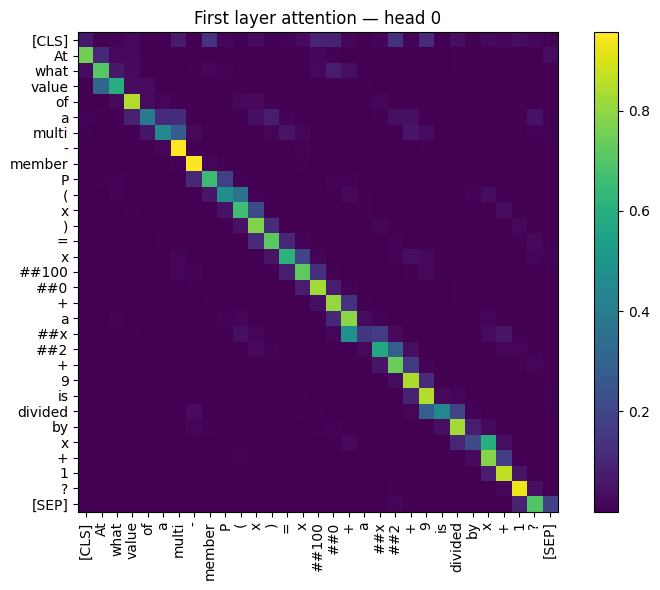

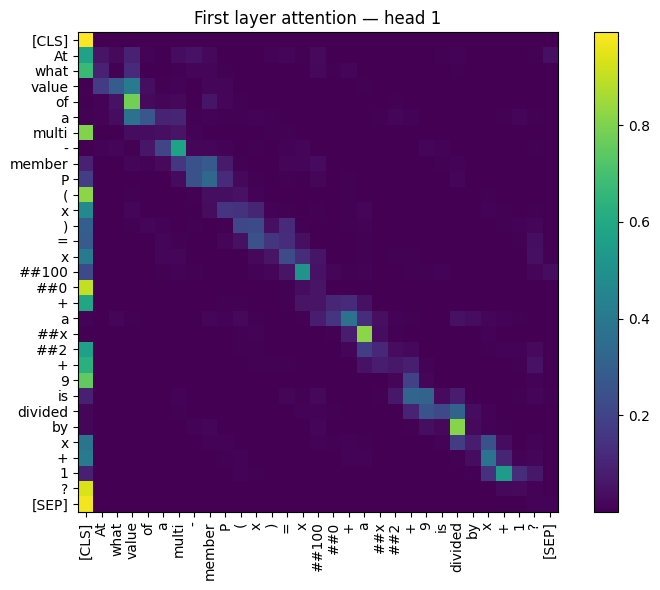

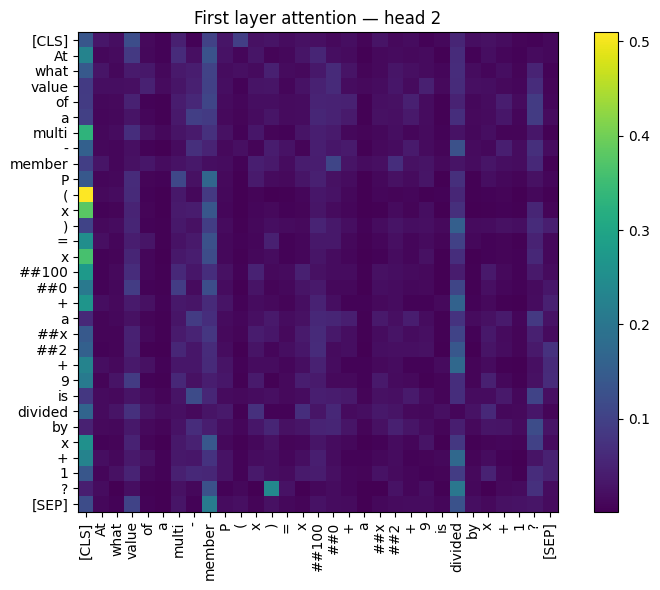

In [ ]:
draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=texts_for_analysis[2],
    model=rubert_base
)

In [ ]:
mathbert_base.eval()

for text in texts_for_analysis:
    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        logits = mathbert_transformer_model(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"]
        )
        pred = logits.argmax(dim=1)

    pred_class = le.inverse_transform(pred.cpu().numpy())

    print("TEXT:")
    print(text)
    print("PREDICTED CLASS:", pred_class[0])
    print("-" * 80)




TEXT:
To prove that the sum of the numbers of the exact square cannot be equal to 5.
PREDICTED CLASS: 1
--------------------------------------------------------------------------------
TEXT:
Prove that if ABCD is a written quadrilateral, the sum of the radius of the circles in the ABC and ACD triangles is equal to the sum of the radius of the circles in the BCD and BDA triangles. Send a comment Decision Page: << 30 31 32 33 35 35 >> [Total tasks: 223] 1 2 5 10 20 50 100 with decisions
PREDICTED CLASS: 4
--------------------------------------------------------------------------------
TEXT:
At what value of a multi-member P(x) = x1000 + ax2 + 9 is divided by x + 1?
PREDICTED CLASS: 4
--------------------------------------------------------------------------------


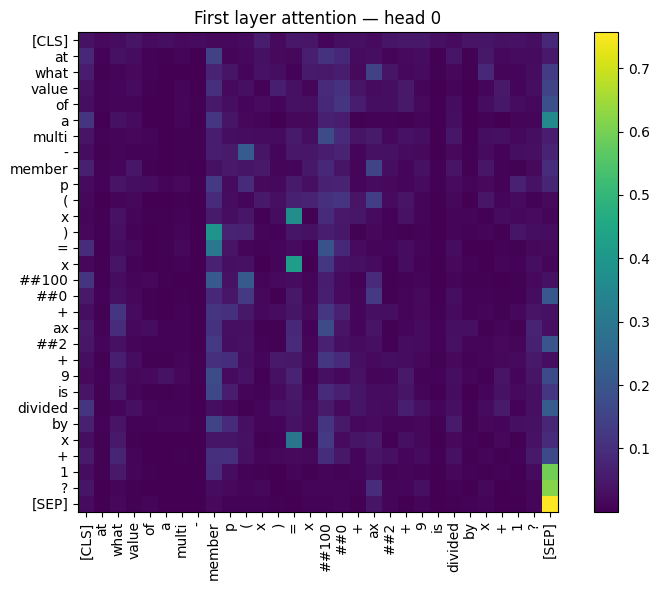

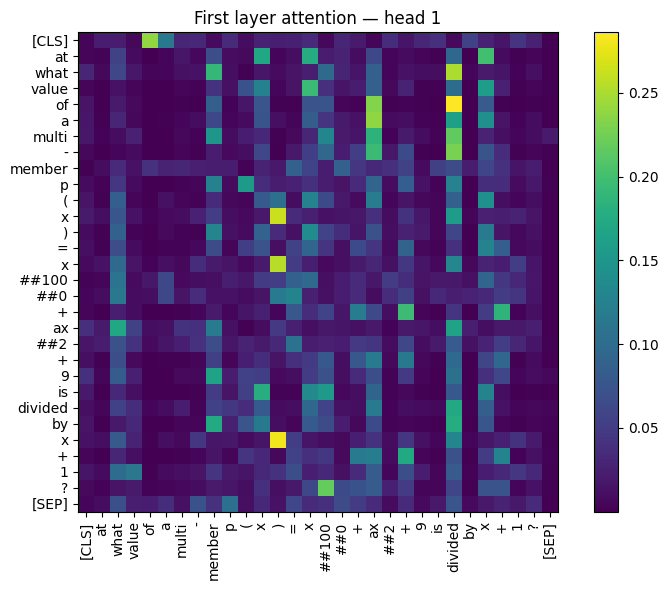

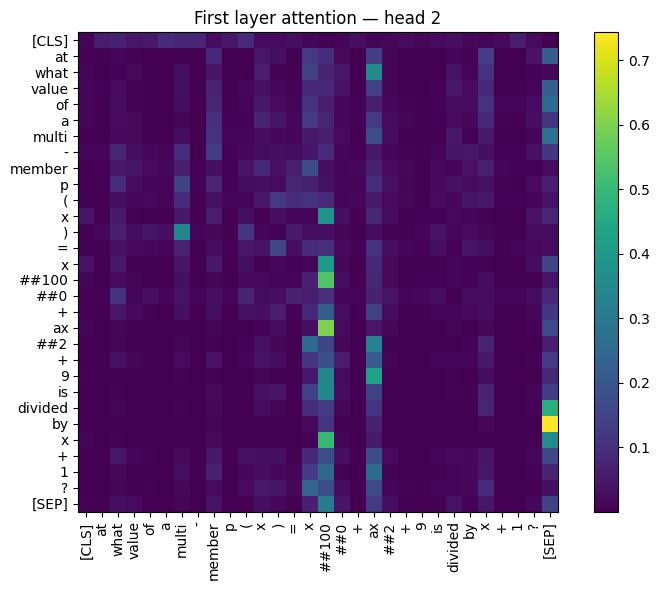

In [ ]:
draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=texts_for_analysis[2],
    model=mathbert_base
)

### Задание 8

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают?

#### rubert tiny

In [ ]:
rubert_tiny_finetuned_with_freezed_backbone.eval()

for text in texts_for_analysis:
    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        logits = rubert_tiny_finetuned_with_freezed_backbone(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"]
        )
        pred = logits.argmax(dim=1)

    pred_class = le.inverse_transform(pred.cpu().numpy())

    print("TEXT:")
    print(text)
    print("PREDICTED CLASS:", pred_class[0])
    print("-" * 80)

TEXT:
To prove that the sum of the numbers of the exact square cannot be equal to 5.
PREDICTED CLASS: 5
--------------------------------------------------------------------------------
TEXT:
Prove that if ABCD is a written quadrilateral, the sum of the radius of the circles in the ABC and ACD triangles is equal to the sum of the radius of the circles in the BCD and BDA triangles. Send a comment Decision Page: << 30 31 32 33 35 35 >> [Total tasks: 223] 1 2 5 10 20 50 100 with decisions
PREDICTED CLASS: 5
--------------------------------------------------------------------------------
TEXT:
At what value of a multi-member P(x) = x1000 + ax2 + 9 is divided by x + 1?
PREDICTED CLASS: 5
--------------------------------------------------------------------------------


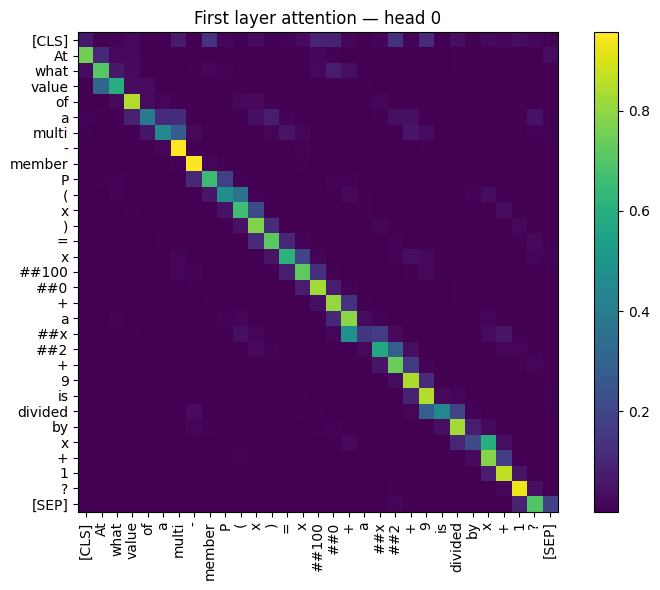

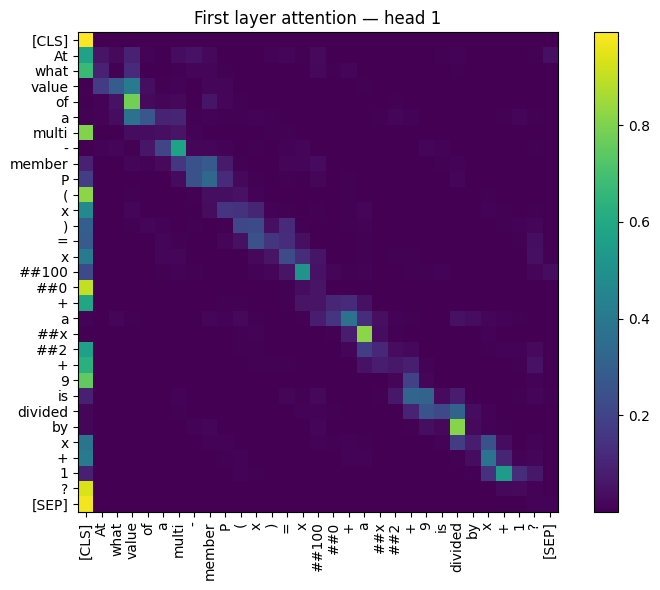

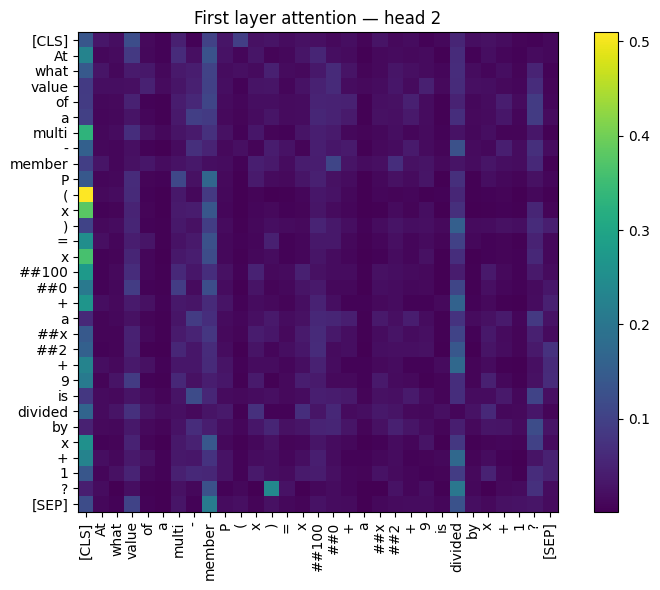

In [ ]:
draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=texts_for_analysis[2],
    model=rubert_tiny_finetuned_with_freezed_backbone
)

In [ ]:
rubert_tiny_full_finetuned.eval()

for text in texts_for_analysis:
    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        logits = rubert_tiny_full_finetuned(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"]
        )
        pred = logits.argmax(dim=1)

    pred_class = le.inverse_transform(pred.cpu().numpy())

    print("TEXT:")
    print(text)
    print("PREDICTED CLASS:", pred_class[0])
    print("-" * 80)

TEXT:
To prove that the sum of the numbers of the exact square cannot be equal to 5.
PREDICTED CLASS: 2
--------------------------------------------------------------------------------
TEXT:
Prove that if ABCD is a written quadrilateral, the sum of the radius of the circles in the ABC and ACD triangles is equal to the sum of the radius of the circles in the BCD and BDA triangles. Send a comment Decision Page: << 30 31 32 33 35 35 >> [Total tasks: 223] 1 2 5 10 20 50 100 with decisions
PREDICTED CLASS: 5
--------------------------------------------------------------------------------
TEXT:
At what value of a multi-member P(x) = x1000 + ax2 + 9 is divided by x + 1?
PREDICTED CLASS: 5
--------------------------------------------------------------------------------


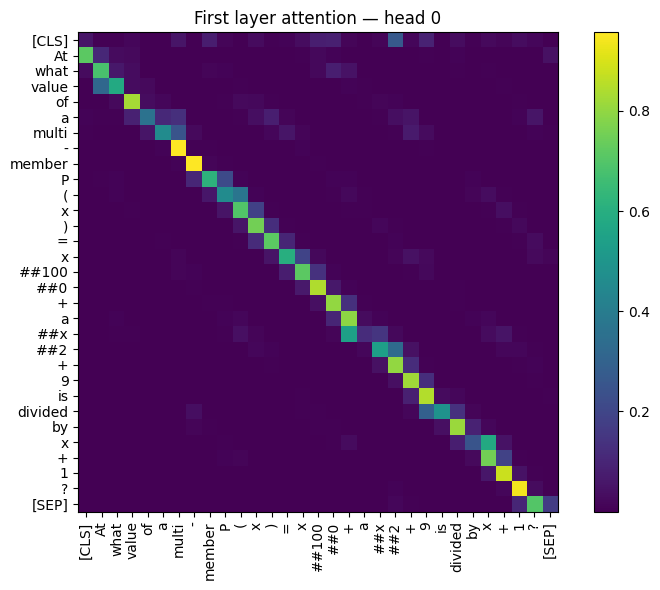

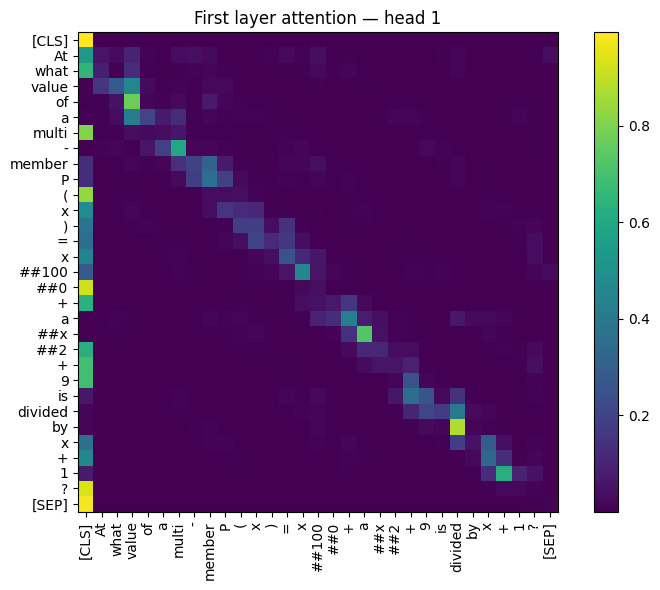

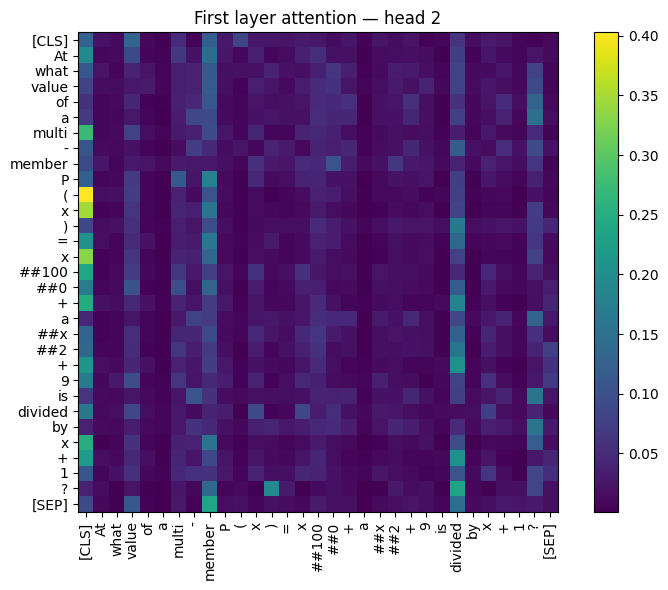

In [ ]:
draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=texts_for_analysis[2],
    model=rubert_tiny_full_finetuned
)

#### mathbert

In [ ]:
mathbert_finetuned_with_freezed_backbone.eval()

for text in texts_for_analysis:
    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        logits = mathbert_finetuned_with_freezed_backbone(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"]
        )
        pred = logits.argmax(dim=1)

    pred_class = le.inverse_transform(pred.cpu().numpy())

    print("TEXT:")
    print(text)
    print("PREDICTED CLASS:", pred_class[0])
    print("-" * 80)

TEXT:
To prove that the sum of the numbers of the exact square cannot be equal to 5.
PREDICTED CLASS: 5
--------------------------------------------------------------------------------
TEXT:
Prove that if ABCD is a written quadrilateral, the sum of the radius of the circles in the ABC and ACD triangles is equal to the sum of the radius of the circles in the BCD and BDA triangles. Send a comment Decision Page: << 30 31 32 33 35 35 >> [Total tasks: 223] 1 2 5 10 20 50 100 with decisions
PREDICTED CLASS: 5
--------------------------------------------------------------------------------
TEXT:
At what value of a multi-member P(x) = x1000 + ax2 + 9 is divided by x + 1?
PREDICTED CLASS: 5
--------------------------------------------------------------------------------


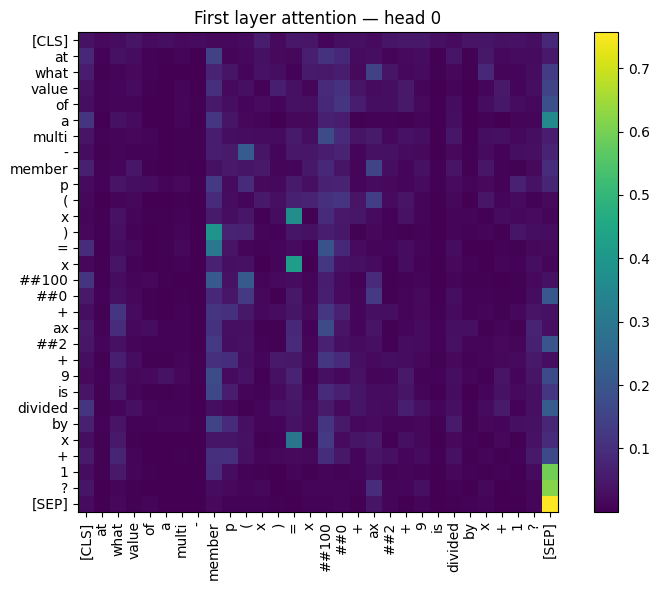

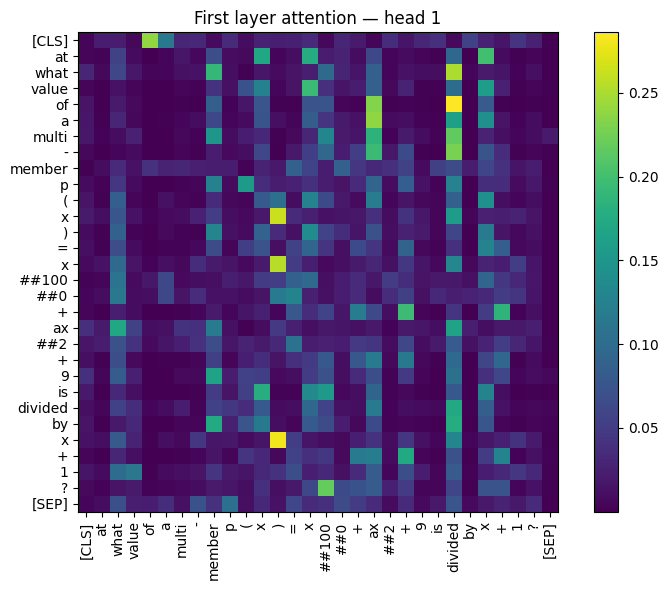

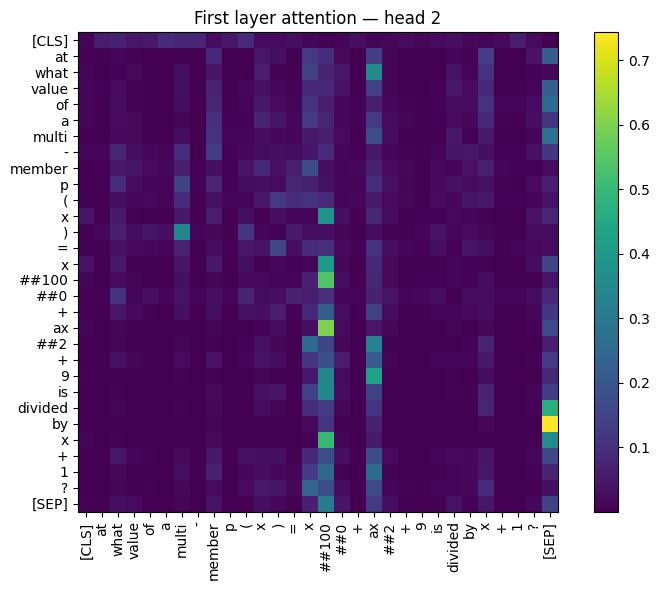

In [ ]:
draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=texts_for_analysis[2],
    model=mathbert_finetuned_with_freezed_backbone
)

In [ ]:
mathbert_full_finetuned.eval()

mathbert_finetuned_with_freezed_backbone.eval()

for text in texts_for_analysis:
    encoding = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        logits = mathbert_full_finetuned(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"]
        )
        pred = logits.argmax(dim=1)

    pred_class = le.inverse_transform(pred.cpu().numpy())

    print("TEXT:")
    print(text)
    print("PREDICTED CLASS:", pred_class[0])
    print("-" * 80)

TEXT:
To prove that the sum of the numbers of the exact square cannot be equal to 5.
PREDICTED CLASS: 5
--------------------------------------------------------------------------------
TEXT:
Prove that if ABCD is a written quadrilateral, the sum of the radius of the circles in the ABC and ACD triangles is equal to the sum of the radius of the circles in the BCD and BDA triangles. Send a comment Decision Page: << 30 31 32 33 35 35 >> [Total tasks: 223] 1 2 5 10 20 50 100 with decisions
PREDICTED CLASS: 2
--------------------------------------------------------------------------------
TEXT:
At what value of a multi-member P(x) = x1000 + ax2 + 9 is divided by x + 1?
PREDICTED CLASS: 6
--------------------------------------------------------------------------------


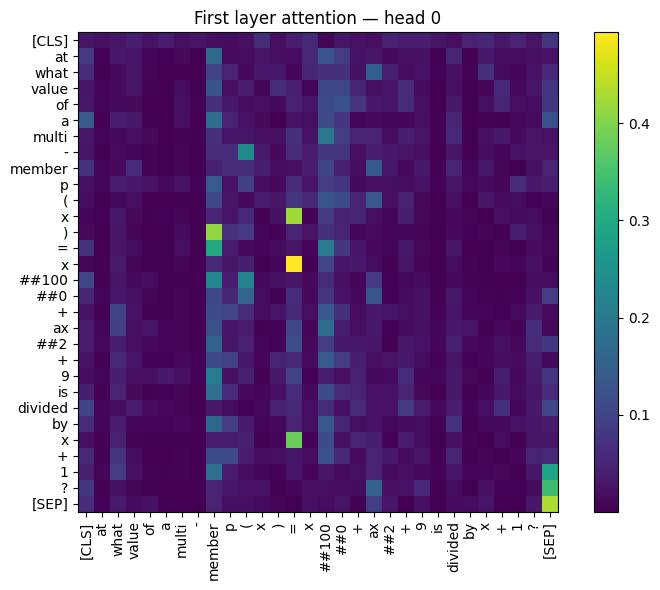

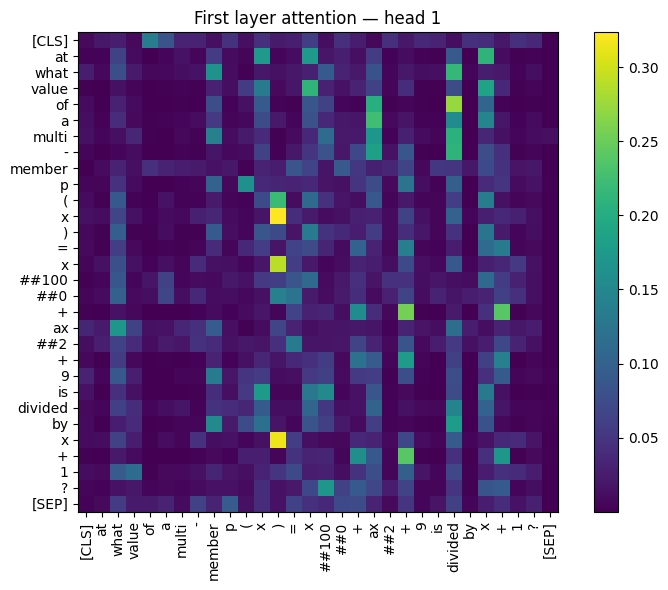

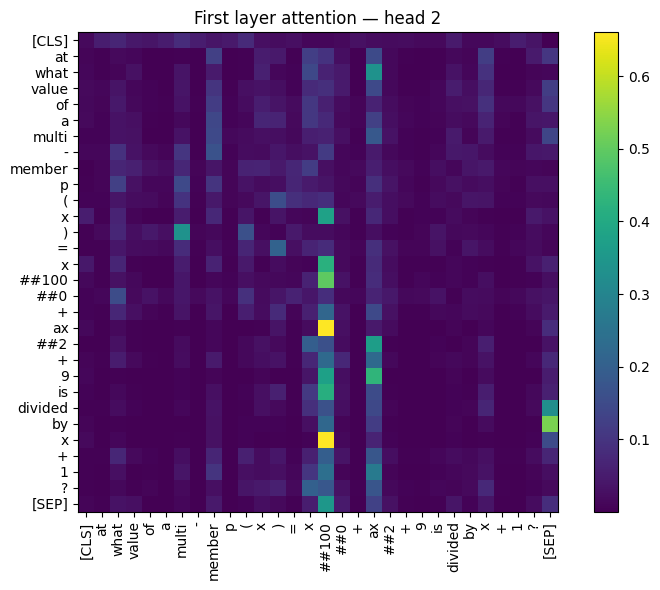

In [ ]:
draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=texts_for_analysis[2],
    model=mathbert_full_finetuned
)

## Вывод

В ходе лабораторной работы были дообучены модели cointegrated/rubert-tiny2 и tbs17/MathBert с заморозкой и без. По картам внимания видно, что cointegrated/rubert-tiny2 больше сосредатачивается на предложении в целом, а tbs17/MathBert на конкретных математических понятиях и их связи между собой. Модель tbs17/MathBert показала лучшие результаты, поскольку она была обучена на математических текстах, в отличие от cointegrated/rubert-tiny2, которая обучена на обычных русских текстах.
